<a href="https://colab.research.google.com/github/bavyasudhir18/ids_codes/blob/main/ids_naive_bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

path = "/content/drive/MyDrive/ids_ds"

print(os.listdir(path))

['X_test_clean.csv', 'y_test.csv', 'y_train.csv', 'X_train_clean.csv']


In [3]:
import pandas as pd

path = "/content/drive/MyDrive/ids_ds"

X_train = pd.read_csv(f"{path}/X_train_clean.csv")
X_test = pd.read_csv(f"{path}/X_test_clean.csv")

y_train = pd.read_csv(f"{path}/y_train.csv")
y_test = pd.read_csv(f"{path}/y_test.csv")

## Phase A: Baseline Gaussian Naive Bayes Model

In this phase, a baseline Gaussian Naive Bayes classifier is developed for network intrusion detection.

Gaussian Naive Bayes is a probabilistic machine learning algorithm based on Bayes' theorem and the assumption of conditional independence among features. For continuous-valued features, the model assumes that each feature follows a Gaussian (normal) distribution within each class.

The model is trained using the preprocessed training dataset and evaluated on both training and testing datasets.

The following performance metrics are computed:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score
- Confusion Matrix
- Classification Report

The objective of this phase is to establish a baseline Naive Bayes model that can later be compared with tuned Naive Bayes and other machine learning algorithms.

In [4]:
from sklearn.naive_bayes import GaussianNB

# Baseline Gaussian Naive Bayes
nb_model = GaussianNB()

# Train
nb_model.fit(X_train, y_train)

print("Gaussian Naive Bayes training completed.")

Gaussian Naive Bayes training completed.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [5]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ==========================
# Training Predictions
# ==========================

y_train_pred = nb_model.predict(X_train)
y_train_prob = nb_model.predict_proba(X_train)[:, 1]

# ==========================
# Testing Predictions
# ==========================

y_test_pred = nb_model.predict(X_test)
y_test_prob = nb_model.predict_proba(X_test)[:, 1]

# ==========================
# Training Metrics
# ==========================

train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
train_auc = roc_auc_score(y_train, y_train_prob)

# ==========================
# Testing Metrics
# ==========================

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_prob)

# ==========================
# Results Table
# ==========================

results_nb = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC'
    ],
    'Training': [
        train_accuracy,
        train_precision,
        train_recall,
        train_f1,
        train_auc
    ],
    'Testing': [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        test_auc
    ]
})

print("="*60)
print("BASELINE GAUSSIAN NAIVE BAYES RESULTS")
print("="*60)

display(results_nb)

BASELINE GAUSSIAN NAIVE BAYES RESULTS


,Metric,Training,Testing
0,Accuracy,0.713955,0.510947
1,Precision,0.694098,0.451078
2,Recall,0.956392,0.697163
3,F1 Score,0.804403,0.547751
4,ROC-AUC,0.871357,0.480875


In [6]:
print("Confusion Matrix")
print(confusion_matrix(y_test, y_test_pred))


print("Classification Report")
print(classification_report(y_test, y_test_pred))

print("="*60)
print("GENERALIZATION ANALYSIS")
print("="*60)

gap = train_accuracy - test_accuracy

print(f"Train Accuracy : {train_accuracy:.4f}")
print(f"Test Accuracy  : {test_accuracy:.4f}")
print(f"Accuracy Gap   : {gap:.4f}")

if gap > 0.05:
    print("Potential Overfitting / Distribution Shift")
else:
    print("Good Generalization")

Confusion Matrix
[[ 6416 10766]
 [ 3843  8847]]
Classification Report
              precision    recall  f1-score   support

           0       0.63      0.37      0.47     17182
           1       0.45      0.70      0.55     12690

    accuracy                           0.51     29872
   macro avg       0.54      0.54      0.51     29872
weighted avg       0.55      0.51      0.50     29872

GENERALIZATION ANALYSIS
Train Accuracy : 0.7140
Test Accuracy  : 0.5109
Accuracy Gap   : 0.2030
Potential Overfitting / Distribution Shift


## Phase B: Stratified 5-Fold Cross-Validation

To evaluate the robustness and stability of the Gaussian Naive Bayes classifier, a Stratified 5-Fold Cross-Validation procedure is performed.

Stratified sampling ensures that the class distribution remains consistent across all folds, providing a reliable estimate of model performance.

The following evaluation metrics are computed for each fold:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score

The mean and standard deviation of each metric are reported to assess the consistency and generalization capability of the model.

In [7]:
import numpy as np
import pandas as pd

from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate

# Ensure target is 1D
y_train_cv = y_train.squeeze()

# Model
nb_cv = GaussianNB()

# Stratified K-Fold
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

# Cross Validation
cv_results = cross_validate(
    nb_cv,
    X_train,
    y_train_cv,
    cv=skf,
    scoring=scoring,
    n_jobs=-1
)

In [8]:
cv_df = pd.DataFrame({
    'Fold': range(1, 6),
    'Accuracy': cv_results['test_accuracy'],
    'Precision': cv_results['test_precision'],
    'Recall': cv_results['test_recall'],
    'F1 Score': cv_results['test_f1'],
    'ROC-AUC': cv_results['test_roc_auc']
})

display(cv_df)

,Fold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,1,0.715729,0.695547,0.956448,0.805395,0.872234
1,2,0.714084,0.694416,0.955627,0.804346,0.869307
2,3,0.715662,0.695511,0.956337,0.805331,0.872327
3,4,0.709687,0.690196,0.957919,0.802313,0.871639
4,5,0.714209,0.694372,0.956173,0.804510,0.871258


In [9]:
summary_df = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC'
    ],
    'Mean': [
        np.mean(cv_results['test_accuracy']),
        np.mean(cv_results['test_precision']),
        np.mean(cv_results['test_recall']),
        np.mean(cv_results['test_f1']),
        np.mean(cv_results['test_roc_auc'])
    ],
    'Std Dev': [
        np.std(cv_results['test_accuracy']),
        np.std(cv_results['test_precision']),
        np.std(cv_results['test_recall']),
        np.std(cv_results['test_f1']),
        np.std(cv_results['test_roc_auc'])
    ]
})

display(summary_df)

,Metric,Mean,Std Dev
0,Accuracy,0.713874,0.002206
1,Precision,0.694008,0.001973
2,Recall,0.956501,0.000763
3,F1 Score,0.804379,0.001116
4,ROC-AUC,0.871353,0.001096


In [10]:
print("="*60)
print("GAUSSIAN NAIVE BAYES - 5 FOLD CV")
print("="*60)

for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    mean_score = np.mean(cv_results[f'test_{metric}'])
    std_score = np.std(cv_results[f'test_{metric}'])

    print(
        f"{metric.upper():<10}: "
        f"{mean_score:.4f} ± {std_score:.4f}"
    )

GAUSSIAN NAIVE BAYES - 5 FOLD CV
ACCURACY  : 0.7139 ± 0.0022
PRECISION : 0.6940 ± 0.0020
RECALL    : 0.9565 ± 0.0008
F1        : 0.8044 ± 0.0011
ROC_AUC   : 0.8714 ± 0.0011


## Phase C: Hyperparameter Tuning using GridSearchCV

In this phase, hyperparameter optimization is performed to identify the optimal variance smoothing parameter for the Gaussian Naive Bayes classifier.

The variance smoothing parameter controls the amount of numerical stability added to the variance estimates during model training. Appropriate smoothing can improve generalization performance and reduce sensitivity to noise.

A GridSearchCV approach combined with Stratified 5-Fold Cross-Validation is employed to identify the best parameter setting.

Objectives:

1. Identify the optimal variance smoothing value.
2. Improve classification performance.
3. Enhance model robustness.
4. Compare tuned performance against the baseline Gaussian Naive Bayes model.

The F1-score is used as the optimization metric because it balances precision and recall, which are both important in intrusion detection systems.

In [11]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

# Model
nb = GaussianNB()

# Parameter Grid
param_grid = {
    'var_smoothing': [
        1e-12,
        1e-11,
        1e-10,
        1e-9,
        1e-8,
        1e-7,
        1e-6,
        1e-5
    ]
}

# Stratified CV
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Grid Search
grid_search = GridSearchCV(
    estimator=nb,
    param_grid=param_grid,
    scoring='f1',
    cv=skf,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(
    X_train,
    y_train.squeeze()
)

print("="*60)
print("BEST PARAMETERS")
print("="*60)

print(grid_search.best_params_)

print("\nBest CV F1 Score:")
print(grid_search.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
BEST PARAMETERS
{'var_smoothing': 1e-05}

Best CV F1 Score:
0.8045446423399873


## Phase D: Evaluation of the Tuned Gaussian Naive Bayes Model

After identifying the optimal variance smoothing parameter through GridSearchCV, the tuned Gaussian Naive Bayes model is evaluated on both the training and testing datasets.

The objective is to assess the model's generalization capability and determine whether hyperparameter tuning improves performance on unseen network traffic.

Performance is measured using:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score

The results are compared against the baseline Gaussian Naive Bayes model to quantify the impact of hyperparameter optimization.

In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Best model
best_nb = grid_search.best_estimator_

# ======================
# Training Predictions
# ======================

y_train_pred = best_nb.predict(X_train)
y_train_prob = best_nb.predict_proba(X_train)[:, 1]

# ======================
# Testing Predictions
# ======================

y_test_pred = best_nb.predict(X_test)
y_test_prob = best_nb.predict_proba(X_test)[:, 1]

# ======================
# Training Metrics
# ======================

train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
train_auc = roc_auc_score(y_train, y_train_prob)

# ======================
# Testing Metrics
# ======================

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_prob)

# ======================
# Results Table
# ======================

results_tuned_nb = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC'
    ],
    'Training': [
        train_accuracy,
        train_precision,
        train_recall,
        train_f1,
        train_auc
    ],
    'Testing': [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        test_auc
    ]
})

display(results_tuned_nb)

,Metric,Training,Testing
0,Accuracy,0.714532,0.509005
1,Precision,0.694704,0.449289
2,Recall,0.955922,0.690150
3,F1 Score,0.804644,0.544262
4,ROC-AUC,0.871361,0.480875


In [13]:
print(confusion_matrix(y_test, y_test_pred))

print(classification_report(y_test, y_test_pred))

gap = train_accuracy - test_accuracy

print(f"Train Accuracy : {train_accuracy:.4f}")
print(f"Test Accuracy  : {test_accuracy:.4f}")
print(f"Accuracy Gap   : {gap:.4f}")

[[ 6447 10735]
 [ 3932  8758]]
              precision    recall  f1-score   support

           0       0.62      0.38      0.47     17182
           1       0.45      0.69      0.54     12690

    accuracy                           0.51     29872
   macro avg       0.54      0.53      0.51     29872
weighted avg       0.55      0.51      0.50     29872

Train Accuracy : 0.7145
Test Accuracy  : 0.5090
Accuracy Gap   : 0.2055


## Phase E.1: ROC Curve Analysis

The Receiver Operating Characteristic (ROC) curve is used to evaluate the classification capability of the tuned Gaussian Naive Bayes model across different probability thresholds.

The ROC curve illustrates the trade-off between the True Positive Rate (Recall) and the False Positive Rate. The Area Under the ROC Curve (ROC-AUC) provides a threshold-independent measure of model discrimination capability.

A higher ROC-AUC score indicates better separation between attack and normal traffic classes.

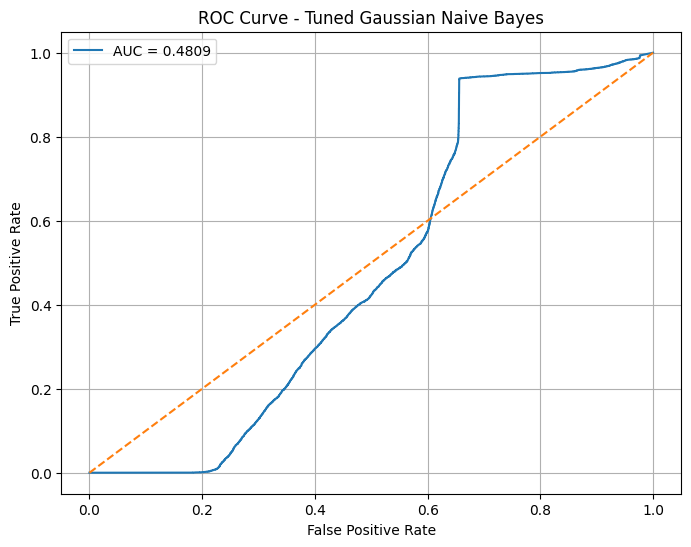

ROC-AUC Score: 0.4809


In [14]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilities
y_prob = best_nb.predict_proba(X_test)[:, 1]

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {auc_score:.4f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Gaussian Naive Bayes")

plt.legend()
plt.grid(True)

plt.show()

print(f"ROC-AUC Score: {auc_score:.4f}")

## Phase E.2: Precision-Recall Curve Analysis

The Precision-Recall curve provides additional insight into model performance, particularly for intrusion detection systems where the balance between attack detection and false alarms is critical.

The curve illustrates the trade-off between precision and recall at different probability thresholds.

The Average Precision (AP) score summarizes the overall quality of the precision-recall relationship.

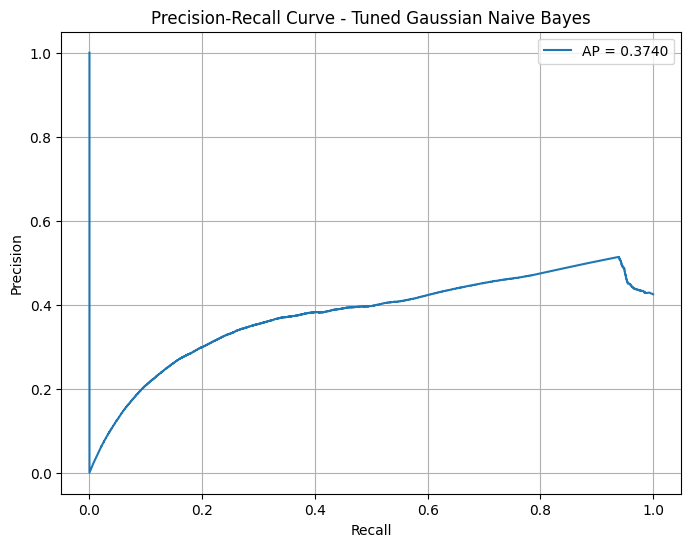

Average Precision Score: 0.3740


In [15]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

ap_score = average_precision_score(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision,
    label=f'AP = {ap_score:.4f}'
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Tuned Gaussian Naive Bayes")

plt.legend()
plt.grid(True)

plt.show()

print(f"Average Precision Score: {ap_score:.4f}")

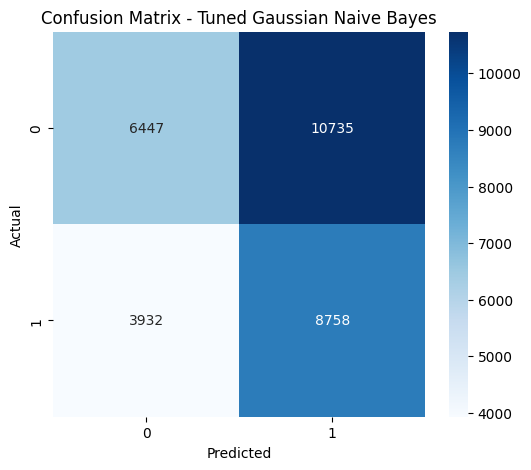

In [16]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned Gaussian Naive Bayes")

plt.show()

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.3,0.515165,0.454938,0.713239,0.555532
1,0.4,0.512185,0.452209,0.701655,0.549969
2,0.5,0.509005,0.449289,0.690150,0.544262
3,0.6,0.505490,0.445984,0.677305,0.537826
4,0.7,0.500536,0.441254,0.659968,0.528892


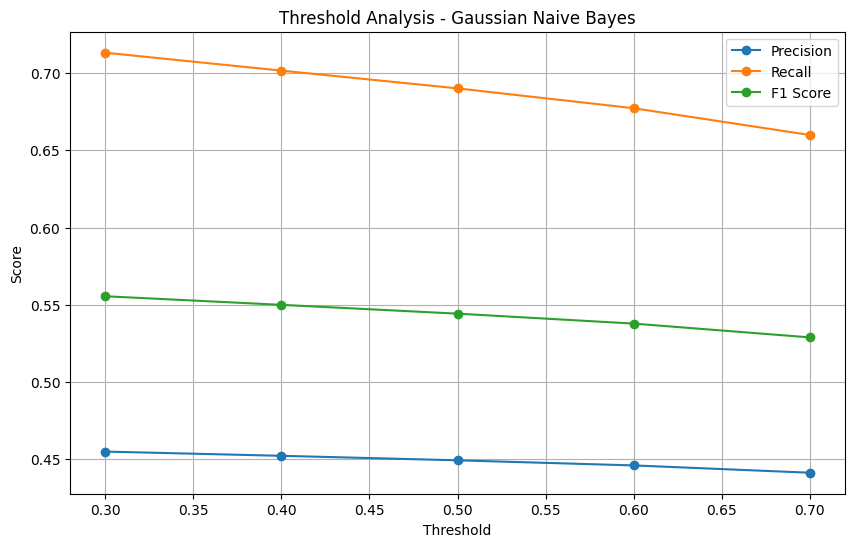

In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

results = []

y_prob = best_nb.predict_proba(X_test)[:, 1]

for threshold in thresholds:

    y_pred_thresh = (y_prob >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_thresh),
        "Precision": precision_score(y_test, y_pred_thresh),
        "Recall": recall_score(y_test, y_pred_thresh),
        "F1 Score": f1_score(y_test, y_pred_thresh)
    })

threshold_df = pd.DataFrame(results)

display(threshold_df)

plt.figure(figsize=(10,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker='o',
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker='o',
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    marker='o',
    label="F1 Score"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis - Gaussian Naive Bayes")

plt.legend()
plt.grid(True)

plt.show()

## Phase F: Feature Importance Analysis using Mutual Information

Unlike Logistic Regression, Gaussian Naive Bayes does not provide interpretable model coefficients for feature importance analysis.

Therefore, Mutual Information (MI) is used to evaluate the dependency between each feature and the target variable.

Mutual Information measures how much information a feature contributes toward predicting the target class. Higher MI values indicate stronger relationships between the feature and the class label.

This analysis helps identify the most informative network traffic characteristics for intrusion detection.

,Feature,Mutual Information
0,tcp_ack,0.663344
1,tcp_window_size,0.541835
2,flow_relative_time,0.429413
3,ip_ttl,0.424125
4,flow_packet_size_stddev,0.337165
5,flow_packet_size_skewness,0.270305
6,flow_packet_size_kurtosis,0.256187
7,flow_packet_count,0.150733
8,tcp_payload_size,0.128170
9,flow_inter_packet_delay,0.126368


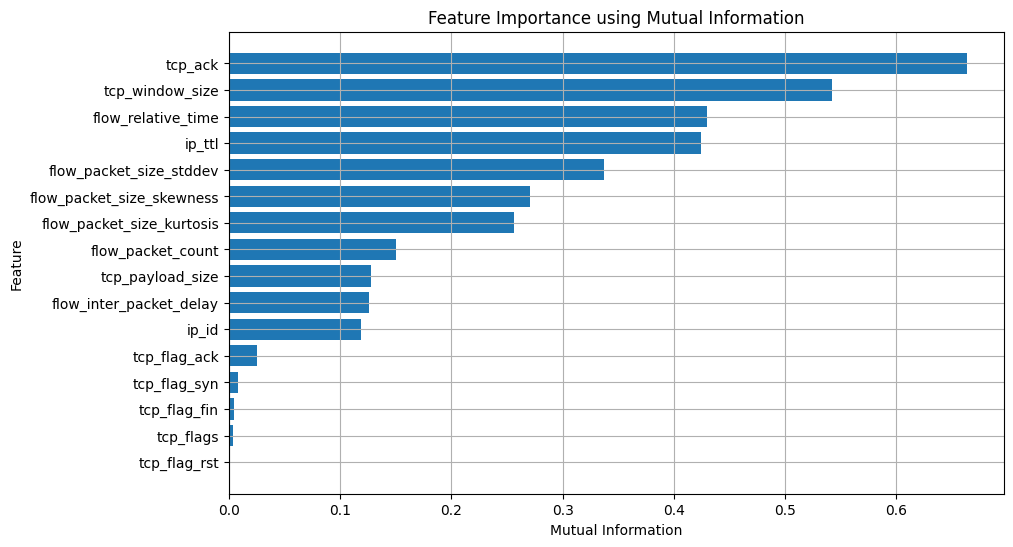

In [20]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Ensure target is 1D
y_train_mi = y_train.squeeze()

# Mutual Information
mi_scores = mutual_info_classif(
    X_train,
    y_train_mi,
    random_state=42
)

# Create DataFrame
mi_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Mutual Information': mi_scores
})

mi_df = mi_df.sort_values(
    by='Mutual Information',
    ascending=False
)

mi_df.reset_index(
    drop=True,
    inplace=True
)

display(mi_df)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    mi_df['Feature'],
    mi_df['Mutual Information']
)

plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.title("Feature Importance using Mutual Information")

plt.gca().invert_yaxis()

plt.grid(True)

plt.show()

## Phase G: Baseline vs Tuned Gaussian Naive Bayes Comparison

In this phase, the performance of the baseline and tuned Gaussian Naive Bayes models is compared.

The objective is to evaluate the impact of hyperparameter tuning on model performance and determine whether optimization improves the classifier's ability to detect network intrusions.

The comparison is performed using:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score

The results help assess whether the tuned model provides meaningful improvements over the baseline implementation.

In [22]:
comparison_nb = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC'
    ],
    'Baseline NB': [
        0.5109,
        0.4510,
        0.6972,
        0.5477,
        0.4809
    ],
    'Tuned NB': [
        0.5090,
        0.4493,
        0.6902,
        0.5440,
        0.4809
    ]
})

comparison_nb['Difference'] = (
    comparison_nb['Tuned NB']
    - comparison_nb['Baseline NB']
)

display(comparison_nb)

,Metric,Baseline NB,Tuned NB,Difference
0,Accuracy,0.5109,0.5090,-0.0019
1,Precision,0.4510,0.4493,-0.0017
2,Recall,0.6972,0.6902,-0.0070
3,F1 Score,0.5477,0.5440,-0.0037
4,ROC-AUC,0.4809,0.4809,0.0000
